In [ ]:
# HyperOpt 를 찾기 위한 기본 루틴 정리본 ,
# 본 파일을 save_as 이니셜_1.모델축약어_FindHO.ipynb 로 저장하세요~ ex) lkj_1.XGB_FindHO.ipynb

In [1]:
import sys
import os

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.datasets import make_classification
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [3]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [4]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [5]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [6]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [7]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [8]:
# 5. 전체 train/test에 대해 스케일링 (SVC용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [9]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [12]:
# ------------------------------------------------
# 2. SVC rbf용 샘플링 (학습 시간 단축)
#    - train에서 다수 클래스만 일부 샘플링
#    - 소수 클래스(사기)는 모두 포함
# ------------------------------------------------
y_train_arr = np.array(y_train)

fraud_idx   = np.where(y_train_arr == 1)[0]
normal_idx  = np.where(y_train_arr == 0)[0]

rng = np.random.default_rng(seed=team_rs)

# 다수 클래스에서 최대 30,000개만 사용 (필요하면 숫자 조절 가능)
normal_sample_size = min(len(normal_idx), 30000)
normal_sample_idx  = rng.choice(normal_idx, size=normal_sample_size, replace=False)

sample_indices = np.concatenate([fraud_idx, normal_sample_idx])

X_svc_base = X_train_scaled[sample_indices]
y_svc_base = y_train_arr[sample_indices]

print(f"[SVC 샘플링] 원본 train 크기: {len(y_train_arr):,}")
print(f"[SVC 샘플링] 샘플링 후 크기: {len(y_svc_base):,}")
print(pd.Series(y_svc_base).value_counts())

[SVC 샘플링] 원본 train 크기: 227,845
[SVC 샘플링] 샘플링 후 크기: 30,394
0    30000
1      394
Name: count, dtype: int64


In [13]:
# ------------------------------------------------
# 3. 샘플링 데이터로 train/val 분리 (HyperOpt용)
# ------------------------------------------------
X_tr_svc, X_val_svc, y_tr_svc, y_val_svc = train_test_split(
    X_svc_base,
    y_svc_base,
    test_size=0.2,
    random_state=team_rs,
    stratify=y_svc_base
)

In [14]:
# ------------------------------------------------
# 4. HyperOpt 튜너 설정 (AUC 기준)
# ------------------------------------------------
tuner = uu.HyperOptTuner(
    max_evals=30,      # SVC는 느리니 30 정도로 시작 (필요시 조절)
    metric="roc_auc",
    random_state=team_rs
)

In [15]:
# ------------------------------------------------
# 5. SVC rbf HyperOpt search space 정의
#    - kernel, probability도 search_space에 넣어서 고정값처럼 사용
# ------------------------------------------------
svc_search_space = {
    "C": hp.loguniform("C", np.log(1e-2), np.log(10)),        # 0.01 ~ 10
    "gamma": hp.loguniform("gamma", np.log(1e-4), np.log(1e-1)),  # 1e-4 ~ 1e-1
    "class_weight": hp.choice("class_weight", [None, "balanced"]),
    "kernel": hp.choice("kernel", ["rbf"]),       # 항상 rbf
    "probability": hp.choice("probability", [True])  # 항상 probability=True (AUC 계산용)
}

svc_model = SVC()

# ------------------------------------------------
# 6. HyperOpt 실행 (샘플링된 데이터 기준)
# ------------------------------------------------
best_svc_params, best_svc_model, svc_trials, svc_time = tuner.tune(
    model=svc_model,
    X_train=X_tr_svc,
    y_train=y_tr_svc,
    X_val=X_val_svc,
    y_val=y_val_svc,
    search_space=svc_search_space,
)

print("\n[SVC-rbf] Best Params:", best_svc_params)
print(f"[SVC-rbf] HyperOpt time: {svc_time:.2f} 초")


SVC 튜닝 시작
100%|██████████| 30/30 [27:10<00:00, 54.35s/trial, best loss: -0.9955548523206751]

튜닝 시간: 1630.57초
최적 roc_auc: 0.9956

최적 모델의 전체 평가 점수:
- roc_auc: 0.9956
- f1: 0.8861
- precision: 0.8861
- recall: 0.8861
- accuracy: 0.9970

[SVC-rbf] Best Params: {'C': 0.17794949104514904, 'class_weight': 'balanced', 'gamma': 0.006213034643966193, 'kernel': 'rbf', 'probability': True}
[SVC-rbf] HyperOpt time: 1630.57 초


In [16]:
# ------------------------------------------------
# 7. 최적 파라미터로 최종 학습/평가
#    7-1) 샘플링만 사용한 버전 (no SMOTE)
#    7-2) 샘플링 + SMOTE 오버샘플링 버전
# ------------------------------------------------

# 7-1) 샘플링만 사용한 버전
svc_sampled = SVC(**best_svc_params)

model_name_sampled = "SVC_rbf_HO_sampled"

results[model_name_sampled] = uu.get_model_train_eval(
    svc_sampled,
    model_name_sampled,
    X_svc_base,        # 학습은 샘플링된 데이터로
    X_test_scaled,     # 평가는 전체 test_scaled
    y_svc_base,
    y_test,
    hyperopt_params=best_svc_params
)

print(f"\n[{model_name_sampled}] 최종 결과:")
print(results[model_name_sampled])

✓ 모델 저장 완료: ../models\SVC_rbf_HO_sampled.pkl
  파일 크기: 0.93 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9733, '정확도': 0.9862, '정밀도': 0.0998, '재현율': 0.8776, 'F1': 0.1792 }
{'오차행렬':
[[56088   776]
 [   12    86]] }
실행 시간: 134.5783109664917
하이퍼파라미터: {'C': 0.17794949104514904, 'class_weight': 'balanced', 'gamma': 0.006213034643966193, 'kernel': 'rbf', 'probability': True}

[SVC_rbf_HO_sampled] 최종 결과:
{'AUC': 0.9733, '정밀도': 0.0998, '재현율': 0.8776, 'F1': 0.1792}


In [17]:
# 7-2) 샘플링 + SMOTE 오버샘플링 버전
X_svc_smote, y_svc_smote = ds.oversampling_smote(
    X_svc_base,
    y_svc_base,
    random_state=team_rs
)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 30394 (Class 0: 30000, Class 1: 394)
   샘플링 후: 60000 (Class 0: 30000, Class 1: 30000)


In [18]:
svc_sampled_smote = SVC(**best_svc_params)

model_name_smote = "SVC_rbf_HO_sampled_SMOTE"

results[model_name_smote] = uu.get_model_train_eval(
    svc_sampled_smote,
    model_name_smote,
    X_svc_smote,      # 학습은 샘플링+SMOTE 데이터
    X_test_scaled,    # 평가는 동일하게 전체 test_scaled
    y_svc_smote,
    y_test,
    hyperopt_params=best_svc_params
)

print(f"\n[{model_name_smote}] 최종 결과:")
print(results[model_name_smote])

✓ 모델 저장 완료: ../models\SVC_rbf_HO_sampled_SMOTE.pkl
  파일 크기: 1.58 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9751, '정확도': 0.9852, '정밀도': 0.0939, '재현율': 0.8776, 'F1': 0.1696 }
{'오차행렬':
[[56034   830]
 [   12    86]] }
실행 시간: 377.36333179473877
하이퍼파라미터: {'C': 0.17794949104514904, 'class_weight': 'balanced', 'gamma': 0.006213034643966193, 'kernel': 'rbf', 'probability': True}

[SVC_rbf_HO_sampled_SMOTE] 최종 결과:
{'AUC': 0.9751, '정밀도': 0.0939, '재현율': 0.8776, 'F1': 0.1696}


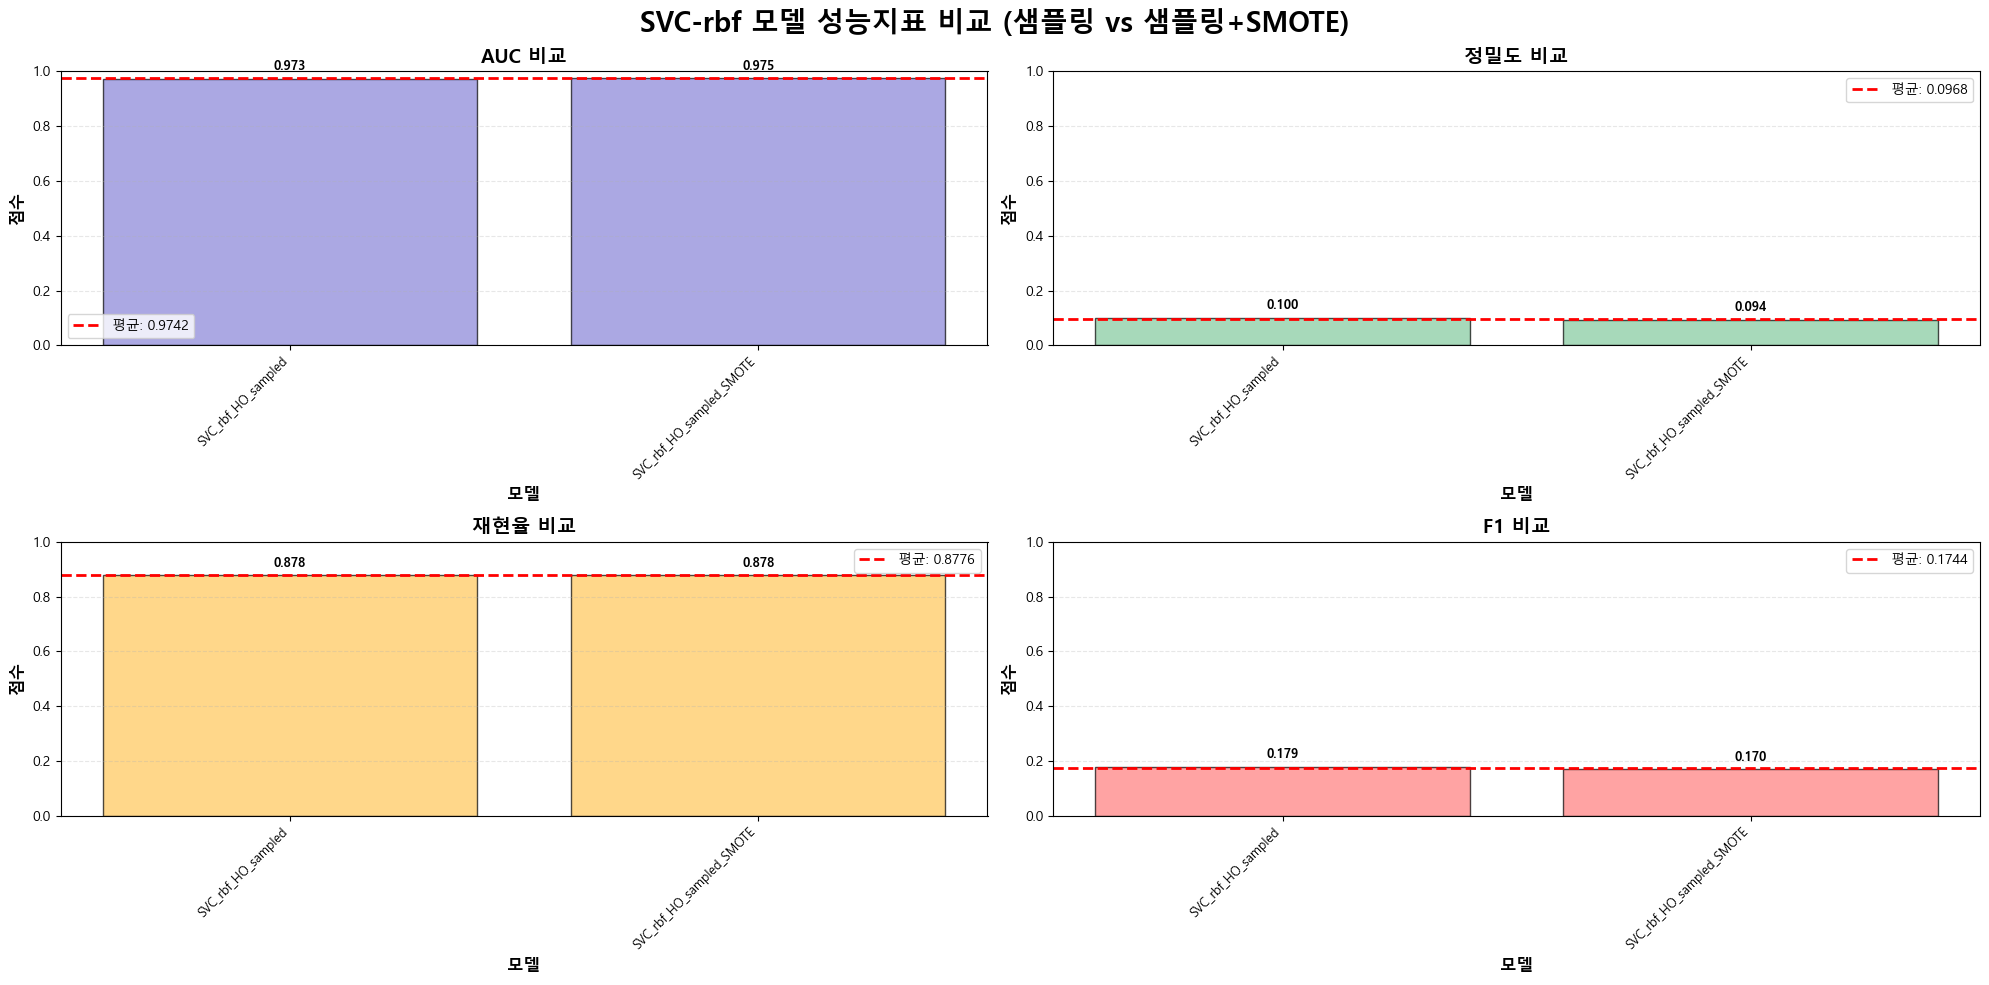


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9751 (SVC_rbf_HO_sampled_SMOTE)
  최저: 0.9733 (SVC_rbf_HO_sampled)
  평균: 0.9742
  표준편차: 0.0013

[정밀도]
  최고: 0.0998 (SVC_rbf_HO_sampled)
  최저: 0.0939 (SVC_rbf_HO_sampled_SMOTE)
  평균: 0.0968
  표준편차: 0.0042

[재현율]
  최고: 0.8776 (SVC_rbf_HO_sampled)
  최저: 0.8776 (SVC_rbf_HO_sampled)
  평균: 0.8776
  표준편차: 0.0000

[F1]
  최고: 0.1792 (SVC_rbf_HO_sampled)
  최저: 0.1696 (SVC_rbf_HO_sampled_SMOTE)
  평균: 0.1744
  표준편차: 0.0068


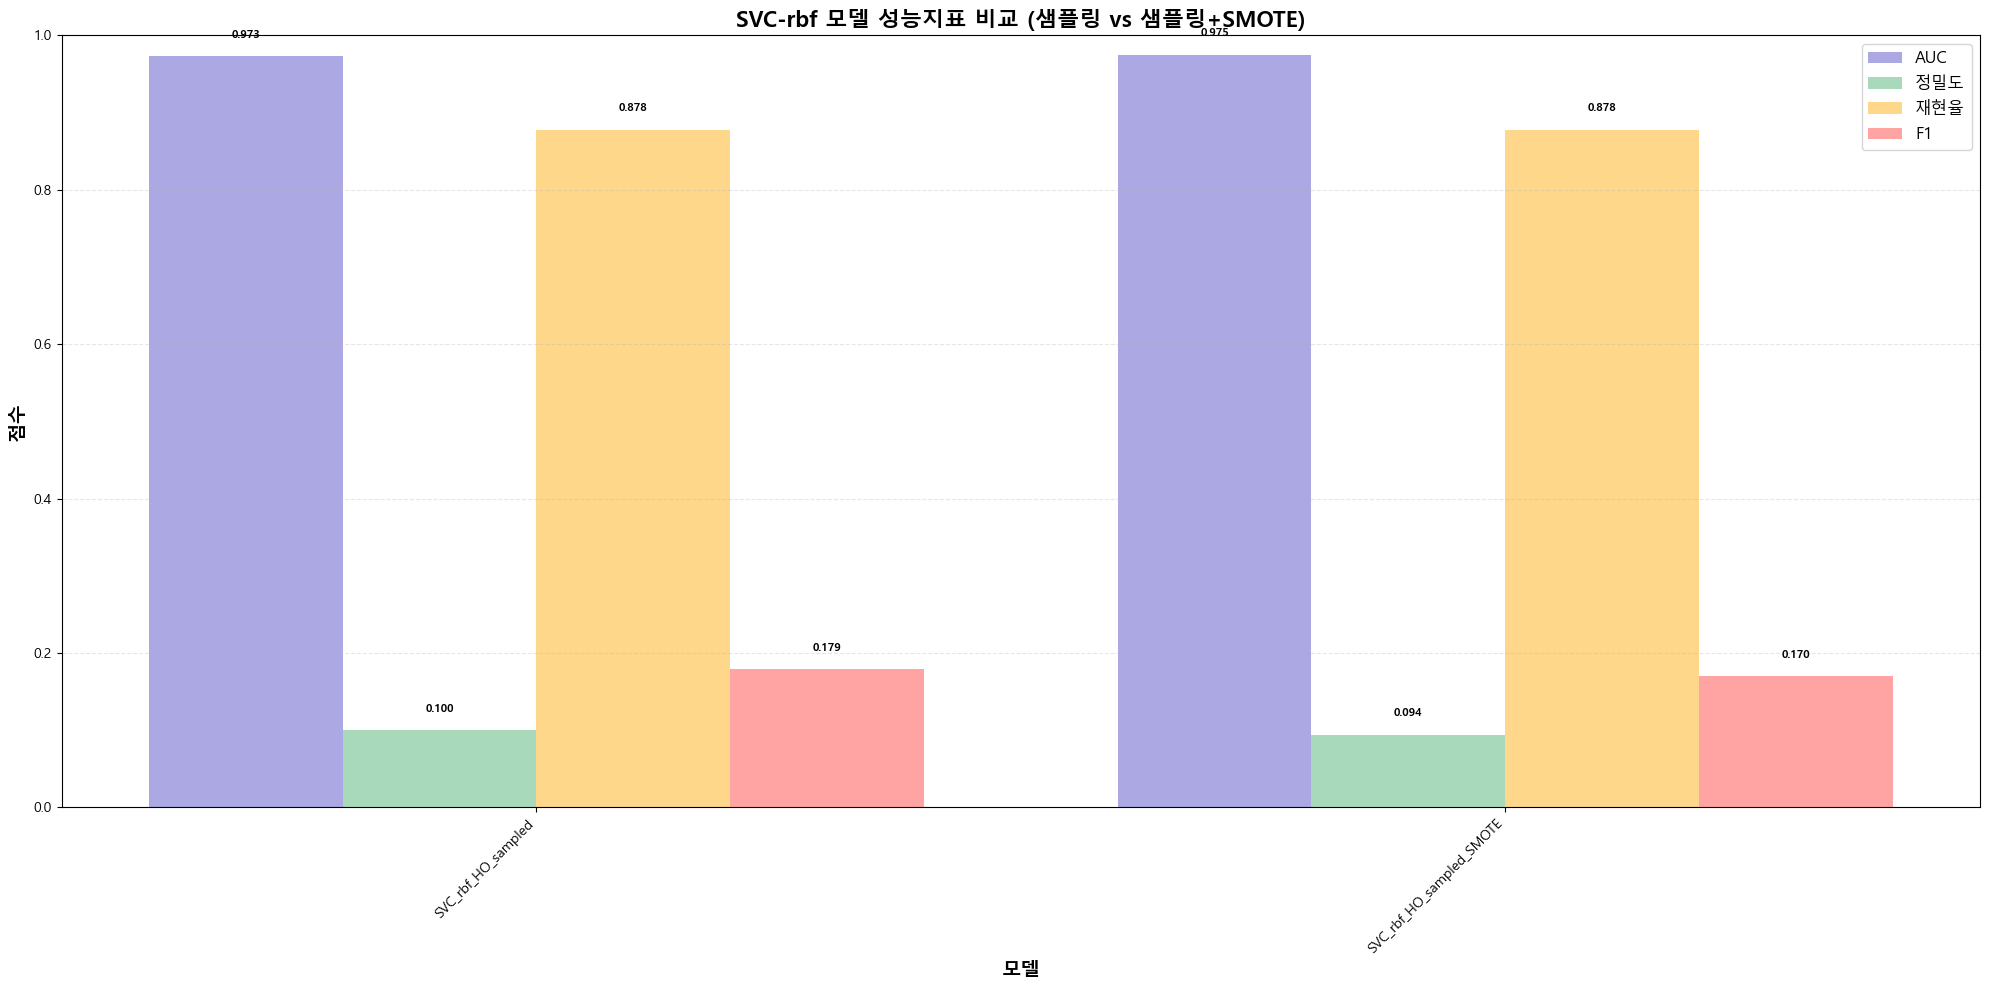


=== F1 Score 기준 상위 5개 모델 ===
                             AUC     정밀도     재현율      F1
SVC_rbf_HO_sampled        0.9733  0.0998  0.8776  0.1792
SVC_rbf_HO_sampled_SMOTE  0.9751  0.0939  0.8776  0.1696

=== AUC 기준 상위 5개 모델 ===
                             AUC     정밀도     재현율      F1
SVC_rbf_HO_sampled_SMOTE  0.9751  0.0939  0.8776  0.1696
SVC_rbf_HO_sampled        0.9733  0.0998  0.8776  0.1792

그래프가 저장되었습니다: ../images/SVC-rbf_모델_성능지표_비교_(샘플링_vs_샘플링+SMOTE)_2025_1201.png


In [19]:
# ------------------------------------------------
# 8. 시각화 (두 버전 비교)
# ------------------------------------------------
mo.model_metrics_graph(results, "SVC-rbf 모델 성능지표 비교 (샘플링 vs 샘플링+SMOTE)")

In [20]:
# ============================================
# thresholds별 튜닝 접근 (LogisticRegression용)
# ============================================

from sklearn.metrics import precision_recall_curve  # 위에서 안 했으면 한 번만 추가

def threshold_tuning_logreg(model, X_test, y_test, model_name="LogReg"):
    """
    - model: 학습 완료된 LogisticRegression (predict_proba 사용 가능)
    - X_test, y_test: 평가용 데이터
    - model_name: 표/그래프 제목용 라벨
    """
    # 1) 예측 확률
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # 2) threshold 그리드 정의 (0.1 ~ 0.9)
    thresholds = np.arange(0.1, 0.91, 0.1)
    results_threshold = []

    for thr in thresholds:
        y_pred_thr = (y_pred_proba >= thr).astype(int)

        precision = precision_score(y_test, y_pred_thr, zero_division=0)
        recall    = recall_score(y_test, y_pred_thr, zero_division=0)
        f1        = f1_score(y_test, y_pred_thr, zero_division=0)
        # AUC는 threshold와 무관하니 한 번만 계산해도 되지만,
        # yjh 코드 스타일 맞춰서 그대로 넣어준다.
        auc       = roc_auc_score(y_test, y_pred_proba)

        results_threshold.append({
            "threshold": thr,
            "precision": precision,
            "recall":    recall,
            "f1":        f1,
            "auc":       auc
        })

    # 3) DataFrame으로 정리
    df_thr = pd.DataFrame(results_threshold)
    print(f"\n==== {model_name} threshold별 성능 ====")
    print(df_thr)

    # 4) Precision-Recall 곡선 시각화
    precisions, recalls, thr_pr = precision_recall_curve(y_test, y_pred_proba)

    plt.figure(figsize=(8, 5))
    plt.plot(thr_pr, precisions[:-1], "b--", label="Precision")
    plt.plot(thr_pr, recalls[:-1],    "g-",  label="Recall")
    plt.title(f"{model_name} - Threshold vs Precision/Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    return df_thr


==== LoR_ho_best threshold별 성능 ====
   threshold  precision    recall        f1       auc
0        0.1   0.009458  0.938776  0.018728  0.965712
1        0.2   0.016627  0.918367  0.032662  0.965712
2        0.3   0.025552  0.897959  0.049689  0.965712
3        0.4   0.036409  0.897959  0.069980  0.965712
4        0.5   0.050406  0.887755  0.095395  0.965712
5        0.6   0.069157  0.887755  0.128319  0.965712
6        0.7   0.094549  0.867347  0.170512  0.965712
7        0.8   0.135703  0.857143  0.234310  0.965712
8        0.9   0.244838  0.846939  0.379863  0.965712


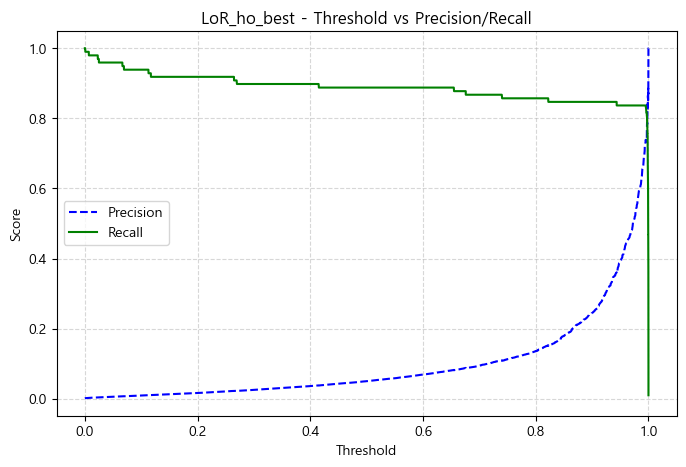

In [21]:
# 기본 LogisticRegression (LoR_ho_best)에 대해 threshold 튜닝
df_thr_log_base = threshold_tuning_logreg(
    model=best_logreg,          # 이미 HyperOpt로 튜닝된 LR
    X_test=X_test_scaled,       # StandardScaler 적용된 원본 test
    y_test=y_test,
    model_name="LoR_ho_best"
)


==== LoR_over_ho_best threshold별 성능 ====
   threshold  precision    recall        f1      auc
0        0.1   0.011313  0.928571  0.022353  0.96424
1        0.2   0.020357  0.918367  0.039832  0.96424
2        0.3   0.029600  0.897959  0.057310  0.96424
3        0.4   0.040807  0.887755  0.078027  0.96424
4        0.5   0.054409  0.887755  0.102534  0.96424
5        0.6   0.071547  0.877551  0.132308  0.96424
6        0.7   0.096552  0.857143  0.173554  0.96424
7        0.8   0.138796  0.846939  0.238506  0.96424
8        0.9   0.224932  0.846939  0.355460  0.96424


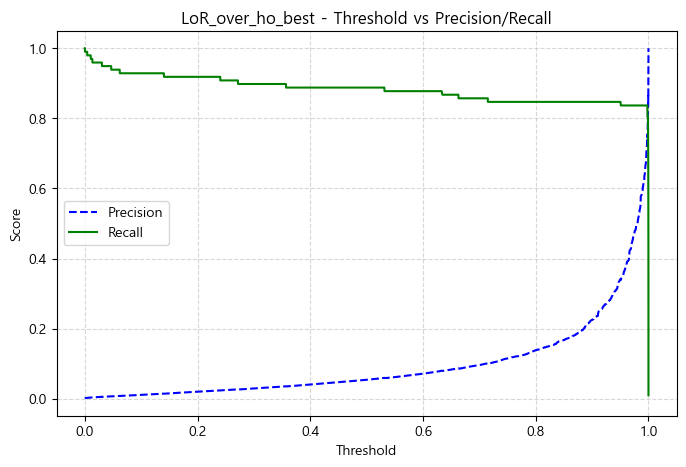

In [22]:
# SMOTE LogisticRegression (LoR_over_ho_best)에 대해 threshold 튜닝
df_thr_log_over = threshold_tuning_logreg(
    model=best_logreg_over,     # SMOTE + HyperOpt 버전 LR
    X_test=X_test_scaled_over,  # SMOTE용 scaler로 변환된 test
    y_test=y_test,
    model_name="LoR_over_ho_best"
)

In [ ]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기
# X_train_scaled, X_test_scaled, scaler = pp.scale_data(X_train, X_test)